In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Brand preference consistency across experiment phases

Both laptop robustness sets: `data/laptops_robustness` (Qwen-2.5) and
`data/laptops_robustness_gemma` (Gemma-3). Full grid, 8 models x 4 constraint
phases = 32 runs.

A **phase** is `{model_size}-{constraint}`, e.g. `32-14_8`. The four constraints are:

| key | prompt says |
|---|---|
| `(none)` | I am looking to buy a laptop. |
| `14` | ... I prefer a 14-inch screen. |
| `8` | ... I prefer 8 GB ram. |
| `14_8` | ... I prefer a 14-inch screen and 8 GB ram. |

Three questions:

1. **Is the brand preference stable across phases?** The constraints never mention brand,
   so under a "the model has a real brand preference" story, brand weights should barely move.
2. **Full vs feature parameterization.** One free weight per laptop (45 params) against one
   weight per feature level summed per laptop (9 params). How much do we lose?
3. Other views that help read the data.

**Gauge note.** Bradley-Terry only identifies *differences* of utility, never absolute levels.
The feature model has one free constant per feature. Everything below is **mean-centered inside
each feature block** (sum-to-zero), so weights are comparable across runs. A brand weight here
means "against the average brand", not an absolute number.

In [2]:
import io
import json
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

from src.pref_models import fit_feature_based_bradley_terry

BASEDIRS = ["data/laptops_robustness", "data/laptops_robustness_gemma"]
CONSTRAINT_ORDER = ["", "14", "8", "14_8"]
CONSTRAINT_LABEL = {"": "none", "14": "14in", "8": "8GB", "14_8": "14in+8GB"}
SIZE_ORDER = {"qwen": ["0.5", "7", "32", "72"], "gemma": ["1", "4", "12", "27"]}
BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
FEATURES = ["brand", "screen", "ram"]

# Palettes checked with the dataviz validator (all-pairs, light surface).
# 5 brands: CVD separation PASS (worst dE 13.0 protan), normal-vision 16.3.
BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
# 3 features: all checks PASS.
FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}

SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list("bl_gy_rd", ["#2a78d6", "#f0efec", "#e34948"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2.0, "font.size": 10,
})

## Setup: fit both Bradley-Terry models on every run

`fit_feature_based_bradley_terry` already lives in `src/pref_models.py`. The **full**
parameterization (one weight per laptop) is new, so it is defined here for now — if it
proves useful we can move it to `src/`.

In [3]:
def item_columns(df, a_prefix="a_", b_prefix="b_"):
    cols_a = [c for c in df.columns if c.startswith(a_prefix)]
    cols_b = [c.replace(a_prefix, b_prefix) for c in cols_a]
    base = [c[len(a_prefix):] for c in cols_a]
    return cols_a, cols_b, base


def join_labels(frame, base):
    """'ASUS-13-inch-4GB' per row. Vectorized - a row-wise .agg('-'.join) here is
    ~60x slower and this runs 4x per run over 32 runs."""
    out = frame[base[0]].astype(str)
    for f in base[1:]:
        out = out + "-" + frame[f].astype(str)
    return out


def fit_full_item_bradley_terry(df, a_prefix="a_", b_prefix="b_",
                                score_a_col="score_a", score_b_col="score_b"):
    """
    FULL parameterization: one free weight per laptop (45 of them). No additivity
    assumption - a laptop's utility is its own parameter, so brand x screen x ram
    interactions are captured.

    Same OLS trick as the feature model: regress (score_a - score_b) on a +1/-1
    design matrix, with an intercept for positional bias. Only utility DIFFERENCES
    are identified, so the weights are mean-centered (sum-to-zero gauge) rather
    than dropping a reference item.
    """
    Y = (df[score_a_col] - df[score_b_col]).values
    cols_a, cols_b, base = item_columns(df, a_prefix, b_prefix)
    lab_a = join_labels(df[cols_a].rename(columns=dict(zip(cols_a, base))), base)
    lab_b = join_labels(df[cols_b].rename(columns=dict(zip(cols_b, base))), base)

    items = sorted(set(lab_a) | set(lab_b))
    idx = {it: i for i, it in enumerate(items)}
    X = np.zeros((len(df), len(items)))
    rows = np.arange(len(df))
    X[rows, lab_a.map(idx).values] = 1.0
    X[rows, lab_b.map(idx).values] = -1.0

    res = sm.OLS(Y, sm.add_constant(X)).fit()   # rank-deficient by 1; pinv returns
    w = np.asarray(res.params[1:])               # the minimum-norm = sum-to-zero fit
    w = w - w.mean()
    return {"item_scores": dict(zip(items, w)),
            "positional_bias_gamma": res.params[0],
            "model_r_squared": res.rsquared,
            "n_params": len(items)}


def center_feature_scores(feature_scores, levels_by_feature):
    """
    fit_feature_based_bradley_terry drops one level per feature (its weight is
    implicitly 0). Add those back, then mean-center each block so every run uses
    the same gauge and the weights can be compared across runs. Differences
    within a feature are unchanged.
    """
    out = {}
    for feat, levels in levels_by_feature.items():
        w = np.array([feature_scores.get(f"{feat}_{lv}", 0.0) for lv in levels], float)
        w = w - w.mean()
        out.update({f"{feat}_{lv}": v for lv, v in zip(levels, w)})
    return out


def fit_feature_bt_with_robust_se(df, a_prefix="a_", b_prefix="b_",
                                  score_a_col="score_a", score_b_col="score_b"):
    """
    Same feature model as src.pref_models.fit_feature_based_bradley_terry, refitted
    here so we can also get CLUSTER-ROBUST standard errors.

    Why: the default fit treats all 9900 rows as independent. They are not. Each
    unordered pair {A,B} appears as (A,B) and (B,A), and each of those is repeated
    over 5 prompt templates - so 10 rows share the same underlying item pair.
    Clustering by unordered pair is the honest standard error.

    Returns a table with both sets of SEs and p-values.
    """
    n = len(df)
    Y = (df[score_a_col] - df[score_b_col]).values
    cols_a, cols_b, base = item_columns(df, a_prefix, b_prefix)
    A = df[cols_a].rename(columns=dict(zip(cols_a, base)))
    B = df[cols_b].rename(columns=dict(zip(cols_b, base)))
    D = pd.get_dummies(pd.concat([A, B], axis=0), drop_first=True, dtype=float)
    X = sm.add_constant(D.iloc[:n].values - D.iloc[n:].values)
    terms = ["gamma (positional bias)"] + D.columns.tolist()

    # cluster id = the UNORDERED pair, so (A,B) and (B,A) land in the same cluster
    lab_a, lab_b = join_labels(A, base), join_labels(B, base)
    lo = np.minimum(lab_a.values.astype(str), lab_b.values.astype(str))
    hi = np.maximum(lab_a.values.astype(str), lab_b.values.astype(str))
    pair_id = pd.Series(np.char.add(np.char.add(lo, "|"), hi)).astype("category").cat.codes

    ols = sm.OLS(Y, X).fit()
    clu = sm.OLS(Y, X).fit(cov_type="cluster", cov_kwds={"groups": pair_id})

    return pd.DataFrame({
        "term": terms, "coef": ols.params,
        "se_ols": ols.bse, "se_cluster": clu.bse,
        "se_inflation": clu.bse / ols.bse,
        "p_ols": ols.pvalues, "p_cluster": clu.pvalues,
    }), {"n_clusters": int(pair_id.nunique()), "r2": ols.rsquared,
         "resid": ols.resid, "pair_id": pair_id.values}

In [4]:
SLUG = {"none": "", "screen=14-inch": "14",
        "ram=8GB": "8", "ram=8GB+screen=14-inch": "14_8"}


def load_all_runs(basedirs=BASEDIRS):
    """One entry per run, keyed by (family, size, constraint). Fits BOTH BT models."""
    runs = {}
    for basedir in basedirs:
        for run in sorted(os.listdir(basedir)):
            cfg_p = os.path.join(basedir, run, "config.json")
            sc_p = os.path.join(basedir, run, "scores.csv")
            if not (os.path.isfile(cfg_p) and os.path.isfile(sc_p)):
                continue
            cfg = json.load(open(cfg_p))
            df = pd.read_csv(sc_p)
            _, _, base = item_columns(df)

            # natural order, not string order ('16GB' sorts before '4GB')
            levels = {"brand": BRANDS,
                      "screen": ["13-inch", "14-inch", "16-inch"],
                      "ram": ["4GB", "8GB", "16GB"]}

            with contextlib.redirect_stdout(io.StringIO()):   # the fitter prints a lot
                feat = fit_feature_based_bradley_terry(df)
            full = fit_full_item_bradley_terry(df)
            centered = center_feature_scores(feat["feature_scores"], levels)
            coef_tbl, diag = fit_feature_bt_with_robust_se(df)

            imap = {}
            for _, row in pd.concat([
                df[[f"a_{f}" for f in base]].rename(columns={f"a_{f}": f for f in base}),
                df[[f"b_{f}" for f in base]].rename(columns={f"b_{f}": f for f in base}),
            ]).drop_duplicates().iterrows():
                imap["-".join(str(row[f]) for f in base)] = {f: row[f] for f in base}

            util_features = {it: sum(centered[f"{f}_{v[f]}"] for f in base)
                             for it, v in imap.items()}

            # config.json stores constraints as a dict since the 2026-08-10 schema
            # change; this notebook still keys on the old short slugs.
            key = (cfg["model_family"], cfg["model_size"], SLUG[cfg["constraints_id"]])
            runs[key] = {
                "family": key[0], "size": key[1], "constraint": key[2],
                "phase": f"{key[1]}-{key[2]}",
                "levels": levels, "base_features": base, "item_feature_map": imap,
                "feature_centered": centered,
                "util_features": util_features,
                "util_full": full["item_scores"],
                "gamma": feat["positional_bias_gamma"],
                "gamma_full": full["positional_bias_gamma"],
                "r2_feature": feat["model_r_squared"],
                "r2_full": full["model_r_squared"],
                "coef_table": coef_tbl,
                "n_clusters": diag["n_clusters"],
                "resid": diag["resid"], "pair_id": diag["pair_id"],
            }
    return runs


RUNS = load_all_runs()
print(f"{len(RUNS)} runs loaded")

# tidy long table of every feature-level weight in every run
WEIGHTS = pd.DataFrame([
    {"family": r["family"], "size": r["size"], "constraint": r["constraint"],
     "phase": r["phase"], "feature": f, "level": lv, "weight": r["feature_centered"][f"{f}_{lv}"]}
    for r in RUNS.values() for f, lvs in r["levels"].items() for lv in lvs
])
WEIGHTS.head()

32 runs loaded


,family,size,constraint,phase,feature,level,weight
0,qwen,72,,72-,brand,ASUS,-0.330355
1,qwen,72,,72-,brand,Apple,1.949544
2,qwen,72,,72-,brand,Dell,0.161156
3,qwen,72,,72-,brand,HP,-0.895270
4,qwen,72,,72-,brand,Lenovo,-0.885074


# 1. Is the brand preference stable across phases?

None of the constraints mention brand. If the model had a firm brand preference, these
lines would be flat.

In [5]:
def order_keys(family):
    """All (family, size, constraint) keys present, in canonical order."""
    return [(family, s, c) for s in SIZE_ORDER[family] for c in CONSTRAINT_ORDER
            if (family, s, c) in RUNS]


brand_tbl = (WEIGHTS[WEIGHTS.feature == "brand"]
             .pivot_table(index=["family", "size", "constraint"], columns="level", values="weight")
             .reindex([(f, s, c) for f in SIZE_ORDER for s in SIZE_ORDER[f] for c in CONSTRAINT_ORDER])
             .dropna(how="all"))
brand_tbl.round(2)

level                   ASUS  Apple  Dell    HP  Lenovo
family size constraint                                 
qwen   0.5              0.04  -0.08 -0.01  0.05   -0.01
            14          0.02  -0.03 -0.00  0.04   -0.02
            8           0.07  -0.14  0.03  0.04    0.01
            14_8        0.06  -0.10  0.01  0.03    0.00
       7                0.34   0.46 -0.13 -0.28   -0.39
            14          0.50  -0.77 -0.00  0.09    0.18
            8           0.29  -0.27 -0.07  0.05    0.00
            14_8        0.44  -0.70  0.07 -0.01    0.20
       32               0.61   2.21 -0.84 -1.60   -0.37
            14          0.67   0.30 -0.38 -0.80    0.20
            8           0.93  -0.74 -0.15 -0.47    0.42
            14_8        0.99  -1.17 -0.04 -0.21    0.44
       72              -0.33   1.95  0.16 -0.90   -0.89
            14          0.00  -0.38  0.56 -0.12   -0.06
            8           0.31  -1.73  0.89  0.23    0.30
            14_8        0.28  -1.73  0.81  0.28    0.37
gemma  1                0.52   1.35 -0.99 -1.41    0.53
            14          0.72   0.76 -0.90 -1.59    1.01
            8           0.76  -0.50 -0.46 -0.69    0.89
            14_8        1.13  -0.22 -0.92 -1.46    1.46
       4                0.01   1.73 -0.50 -1.67    0.43
            14          0.74  -0.41 -0.03 -0.86    0.56
            8           0.42  -0.92  0.12 -0.32    0.70
            14_8        0.99  -1.39  0.17 -0.45    0.69
       12               0.19   1.28 -0.58 -1.18    0.29
            14          0.53  -0.23 -0.31 -0.35    0.37
            8           0.72  -1.80  0.10  0.01    0.97
            14_8        0.64  -1.46 -0.05  0.18    0.69
       27               0.18   2.74 -0.98 -2.14    0.19
            14          0.73  -0.52 -0.25 -0.62    0.65
            8           0.89  -1.36  0.06 -0.54    0.94
            14_8        1.03  -1.87  0.03  0.01    0.80

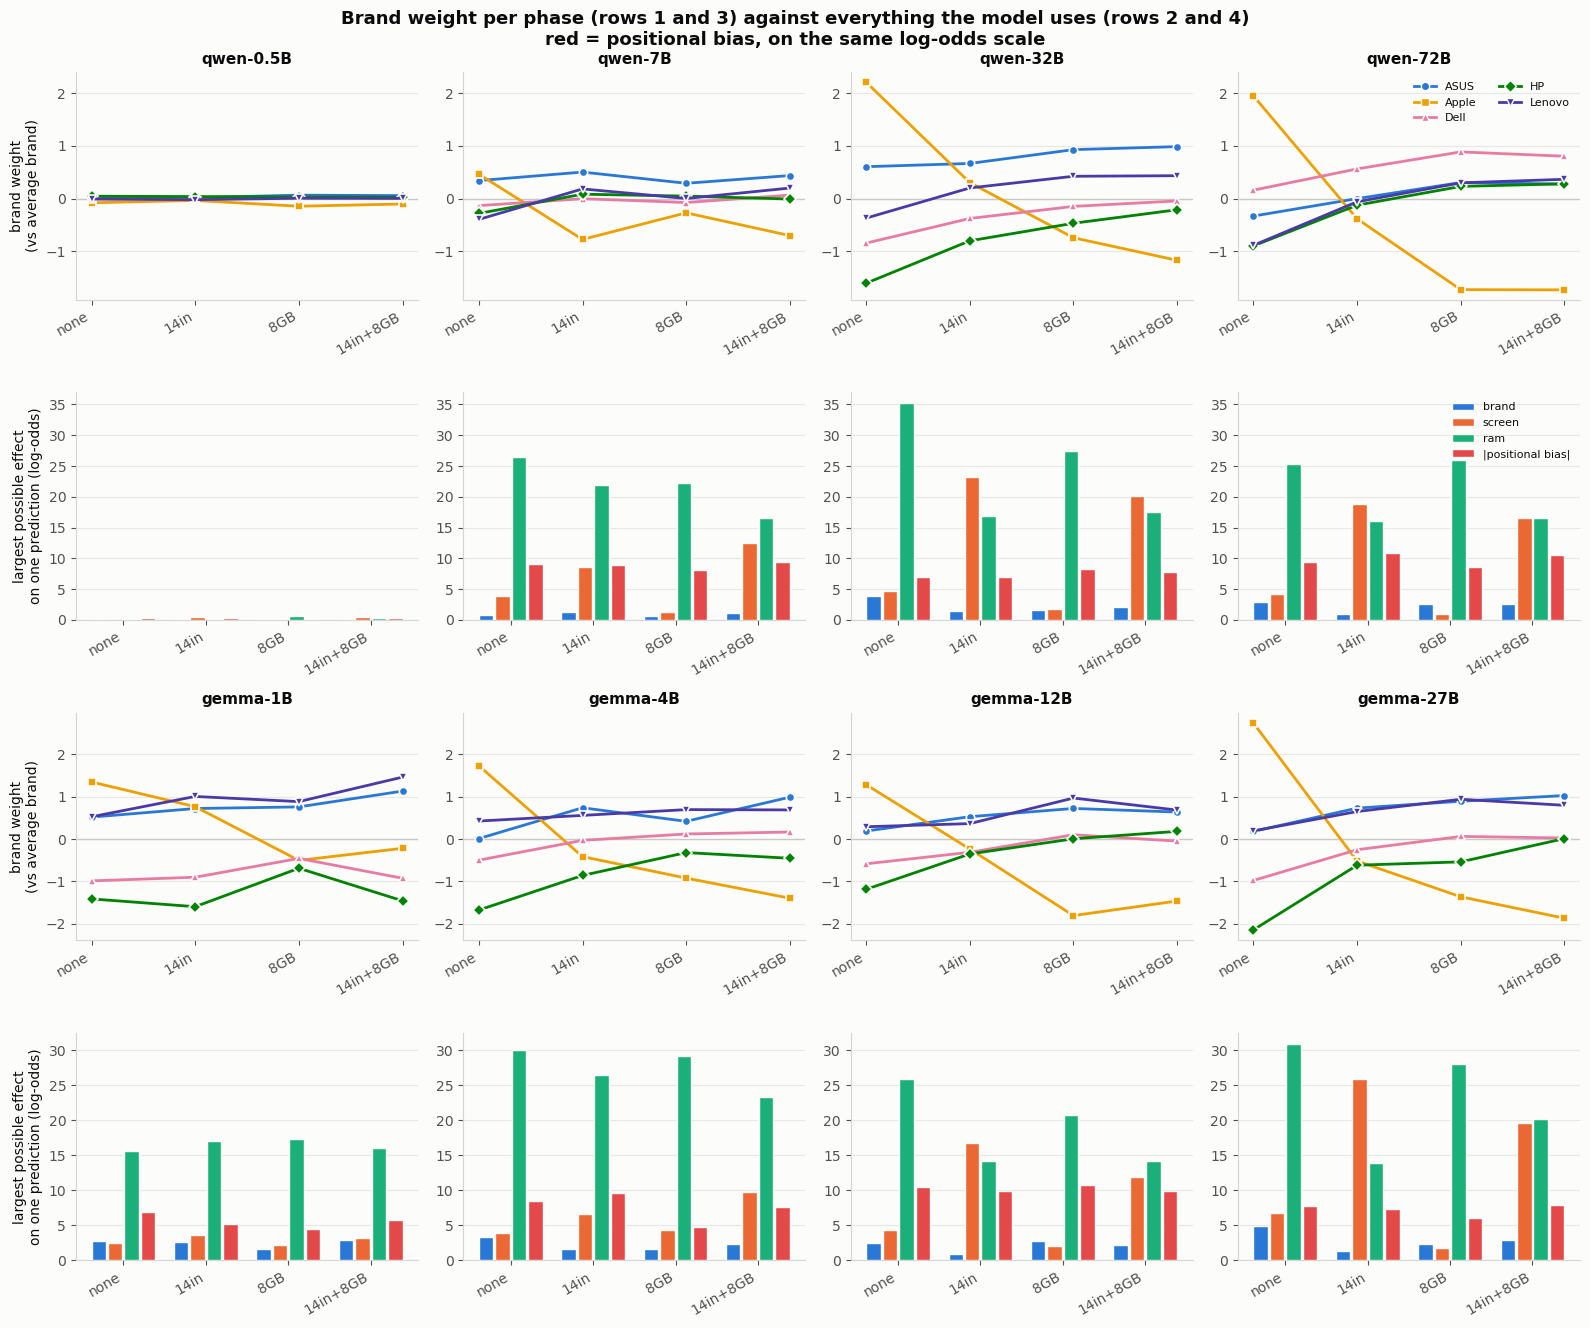

In [6]:
# --- Fig 1.1  brand trajectories (top row of each pair) with the WHOLE model
#     underneath, so the positional bias can be judged against everything.
#
# A prediction for an ordered pair is   gamma + (u_A - u_B),
# and  u_A - u_B  is the sum over features of (weight of A's level - weight of B's level).
# So a feature's biggest possible contribution to one prediction is exactly the RANGE
# of its own weights (best level - worst level). That makes the feature ranges and
# |gamma| directly comparable: the lower panels put them side by side.

fig, axes = plt.subplots(4, 4, figsize=(16, 13.5))
for pair_i, family in enumerate(["qwen", "gemma"]):
    top, bot = axes[2 * pair_i], axes[2 * pair_i + 1]
    for col, size in enumerate(SIZE_ORDER[family]):
        keys = [(family, size, c) for c in CONSTRAINT_ORDER if (family, size, c) in RUNS]
        x = np.arange(len(keys))
        labels = [CONSTRAINT_LABEL[k[2]] for k in keys]

        # ---- brand only, readable scale ----
        ax = top[col]
        for brand in BRANDS:
            ax.plot(x, [RUNS[k]["feature_centered"][f"brand_{brand}"] for k in keys],
                    color=BRAND_COLOR[brand], marker=BRAND_MARKER[brand], markersize=6,
                    markeredgecolor=SURFACE, markeredgewidth=1.2, label=brand, zorder=3)
        ax.axhline(0, color="#c9c8c4", linewidth=1, zorder=1)
        ax.set_xticks(x, labels, rotation=30, ha="right")
        ax.set_title(f"{family}-{size}B", fontsize=11, fontweight="bold")
        ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
        if col == 0:
            ax.set_ylabel("brand weight\n(vs average brand)")

        # ---- the whole model: what each feature can contribute, vs the bias ----
        ax = bot[col]
        w = 0.2
        for i, feat in enumerate(FEATURES):
            rng = [max(RUNS[k]["feature_centered"][f"{feat}_{lv}"] for lv in RUNS[k]["levels"][feat])
                   - min(RUNS[k]["feature_centered"][f"{feat}_{lv}"] for lv in RUNS[k]["levels"][feat])
                   for k in keys]
            ax.bar(x + (i - 1.5) * w, rng, w * 0.88, color=FEATURE_COLOR[feat],
                   edgecolor=SURFACE, linewidth=1, label=feat, zorder=3)
        ax.bar(x + 1.5 * w, [abs(RUNS[k]["gamma"]) for k in keys], w * 0.88,
               color="#e34948", edgecolor=SURFACE, linewidth=1,
               label="|positional bias|", zorder=3)
        ax.set_xticks(x, labels, rotation=30, ha="right")
        ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
        if col == 0:
            ax.set_ylabel("largest possible effect\non one prediction (log-odds)")

    for row in (top, bot):                       # shared y within each row
        lo = min(a.get_ylim()[0] for a in row)
        hi = max(a.get_ylim()[1] for a in row)
        for a in row:
            a.set_ylim(lo, hi)

brand_h = [Line2D([], [], color=BRAND_COLOR[b], marker=BRAND_MARKER[b], markersize=6,
                  markeredgecolor=SURFACE, label=b) for b in BRANDS]
axes[0, 3].legend(handles=brand_h, fontsize=8, frameon=False, ncol=2, loc="upper right")
axes[1, 3].legend(fontsize=8, frameon=False, loc="upper right")
fig.suptitle("Brand weight per phase (rows 1 and 3) against everything the model uses "
             "(rows 2 and 4)\nred = positional bias, on the same log-odds scale",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

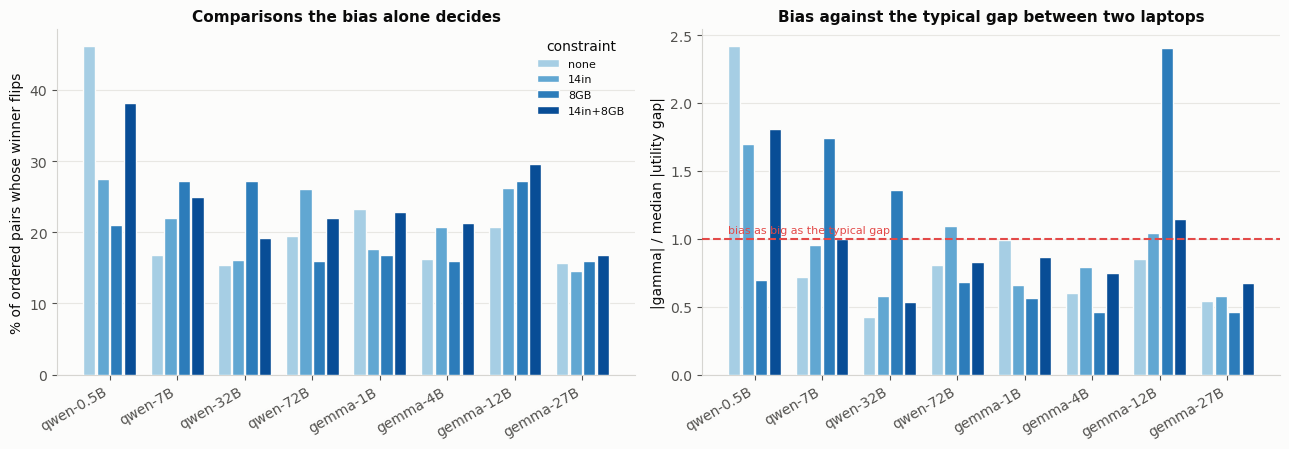

constraint           14  14_8     8
family size                        
gemma  1     23.2  17.6  22.9  16.9
       12    20.8  26.2  29.6  27.3
       27    15.7  14.5  16.8  15.9
       4     16.3  20.7  21.3  16.0
qwen   0.5   46.2  27.5  38.2  21.1
       32    15.5  16.2  19.2  27.3
       7     16.9  22.0  25.0  27.3
       72    19.4  26.0  22.0  15.9

In [7]:
# --- Fig 1.2  the bluntest version of the same question:
#     how often does the bias alone change WHO WINS the comparison?
#
# predicted log-odds for the ordered pair (A,B) = gamma + (u_A - u_B).
# Without the bias it would just be (u_A - u_B). The bias flips the predicted
# winner whenever the two disagree in sign.
import itertools

rows = []
for family in ["qwen", "gemma"]:
    for size in SIZE_ORDER[family]:
        for c in CONSTRAINT_ORDER:
            r = RUNS.get((family, size, c))
            if r is None:
                continue
            u = np.array(list(r["util_features"].values()))
            du = np.array([a - b for a, b in itertools.permutations(u, 2)])
            g = r["gamma"]
            rows.append({
                "family": family, "size": size, "constraint": c,
                "flip_pct": 100 * float((np.sign(du + g) != np.sign(du)).mean()),
                "bias_vs_typical_gap": abs(g) / float(np.median(np.abs(du))),
            })
FLIP = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (col, title, ylab, ref) in zip(axes, [
        ("flip_pct", "Comparisons the bias alone decides",
         "% of ordered pairs whose winner flips", None),
        ("bias_vs_typical_gap", "Bias against the typical gap between two laptops",
         "|gamma| / median |utility gap|", 1.0)]):
    piv = (FLIP.pivot_table(index=["family", "size"], columns="constraint", values=col)
           .reindex([(f, s) for f in SIZE_ORDER for s in SIZE_ORDER[f]])[CONSTRAINT_ORDER])
    x = np.arange(len(piv))
    for j, c in enumerate(CONSTRAINT_ORDER):
        ax.bar(x + (j - 1.5) * 0.2, piv[c].values, 0.18,
               color=plt.get_cmap("Blues")(0.35 + 0.18 * j),
               edgecolor=SURFACE, linewidth=1, label=CONSTRAINT_LABEL[c], zorder=3)
    if ref is not None:
        ax.axhline(ref, color="#e34948", linewidth=1.5, linestyle="--", zorder=4)
        ax.text(-0.4, ref * 1.03, "bias as big as the typical gap",
                fontsize=8, color="#e34948", va="bottom")
    ax.set_xticks(x, [f"{f}-{s}B" for f, s in piv.index], rotation=30, ha="right")
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
axes[0].legend(title="constraint", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

FLIP.pivot_table(index=["family", "size"], columns="constraint", values="flip_pct").round(1)

**This is the number to remember.** For every model except the noise-level qwen-0.5B, the
positional bias alone changes the predicted winner in **15% to 30% of all comparisons** —
even though it carries no information about the laptops at all. And `|gamma|` is roughly the
same size as the median utility gap between two random laptops (ratio ~0.5-1.2).

So the bias is not a small nuisance term to note and move on from. It is the same order of
magnitude as the entire preference signal we are trying to measure.

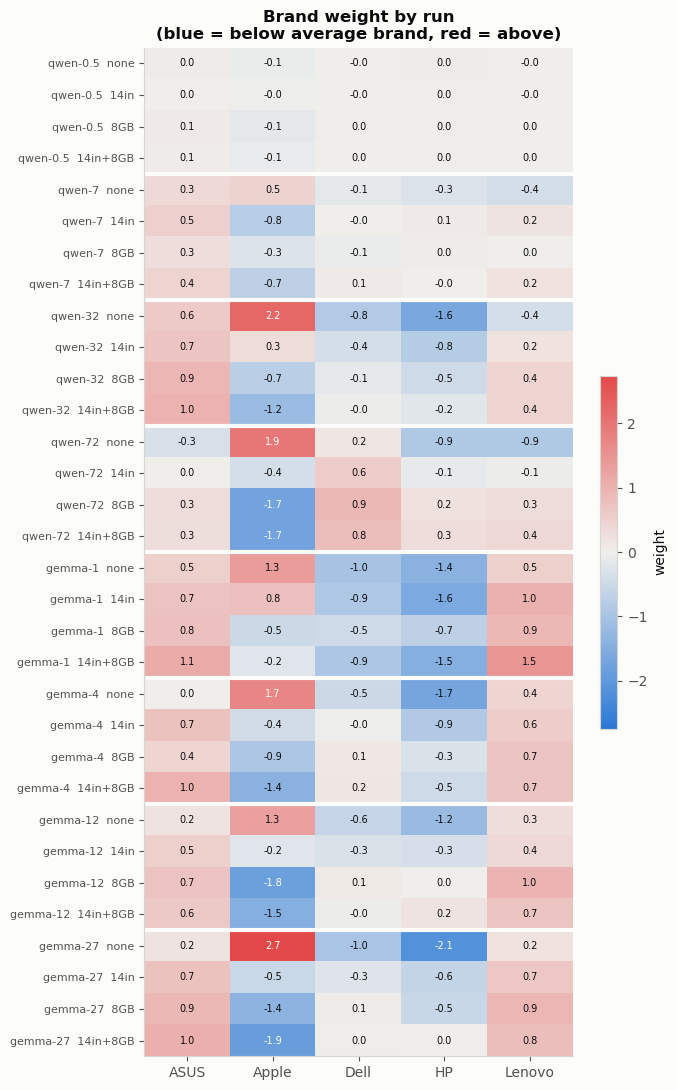

In [8]:
# --- Fig 1.3  the same numbers as a heatmap, so the whole grid is on one screen ---
mat = brand_tbl[BRANDS]
labels = [f"{f}-{s}  {CONSTRAINT_LABEL[c]}" for f, s, c in mat.index]
vmax = float(np.abs(mat.values).max())

fig, ax = plt.subplots(figsize=(7, 11))
im = ax.imshow(mat.values, cmap=DIVERGING, norm=TwoSlopeNorm(0, -vmax, vmax), aspect="auto")
ax.set_xticks(range(len(BRANDS)), BRANDS)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
                color="#ffffff" if abs(v) > 0.62 * vmax else INK)
for i in range(4, mat.shape[0], 4):                       # separate the models
    ax.axhline(i - 0.5, color=SURFACE, linewidth=3)
ax.set_title("Brand weight by run\n(blue = below average brand, red = above)",
             fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.35, label="weight")
ax.grid(False)
plt.tight_layout()
plt.show()

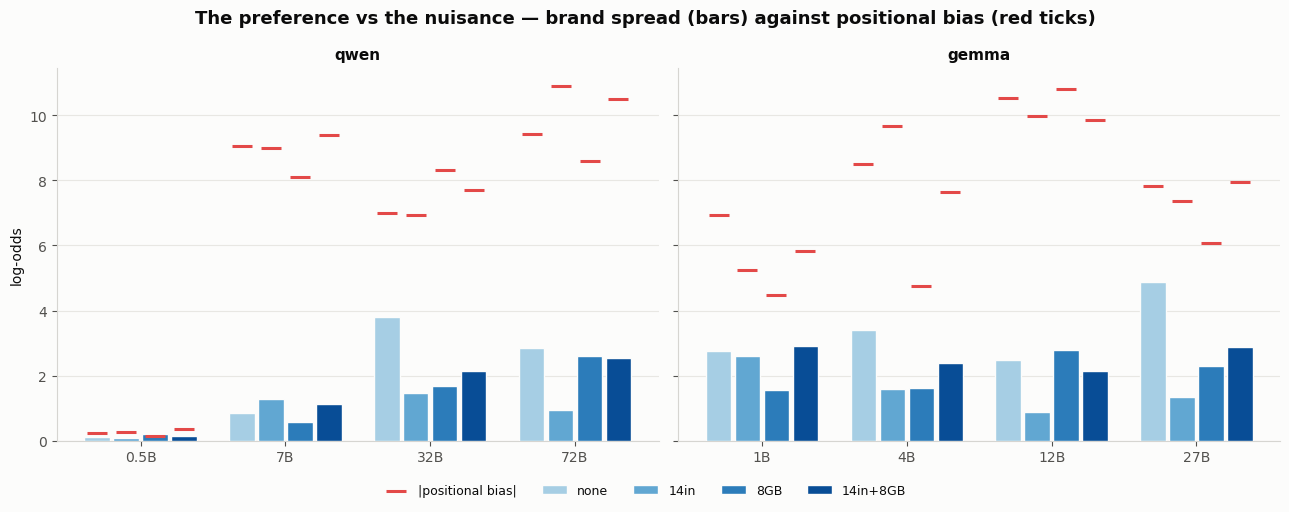

In [9]:
# --- Fig 1.4  brand signal vs the positional bias, same units ---
# Both are log-odds, so they belong on ONE axis. This is the comparison that
# matters: is the preference we are measuring bigger than the nuisance?
spread = (WEIGHTS[WEIGHTS.feature == "brand"]
          .groupby(["family", "size", "constraint"])["weight"]
          .agg(lambda s: s.max() - s.min()).rename("spread").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
width = 0.2
for ax, family in zip(axes, ["qwen", "gemma"]):
    sub = spread[spread.family == family]
    sizes = SIZE_ORDER[family]
    x = np.arange(len(sizes))
    for i, c in enumerate(CONSTRAINT_ORDER):
        vals = [sub[(sub["size"] == s) & (sub.constraint == c)]["spread"].squeeze() for s in sizes]
        ax.bar(x + (i - 1.5) * width, vals, width * 0.88,
               color=plt.get_cmap("Blues")(0.35 + 0.18 * i),
               edgecolor=SURFACE, linewidth=1, label=CONSTRAINT_LABEL[c], zorder=3)
        gam = [abs(RUNS[(family, s, c)]["gamma"]) if (family, s, c) in RUNS else np.nan
               for s in sizes]
        ax.scatter(x + (i - 1.5) * width, gam, marker="_", s=190, color="#e34948",
                   linewidths=2.2, zorder=5,
                   label="|positional bias|" if i == 0 else None)
    ax.set_xticks(x, [f"{s}B" for s in sizes])
    ax.set_title(family, fontsize=11, fontweight="bold")
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
axes[0].set_ylabel("log-odds")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle("The preference vs the nuisance — brand spread (bars) against "
             "positional bias (red ticks)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

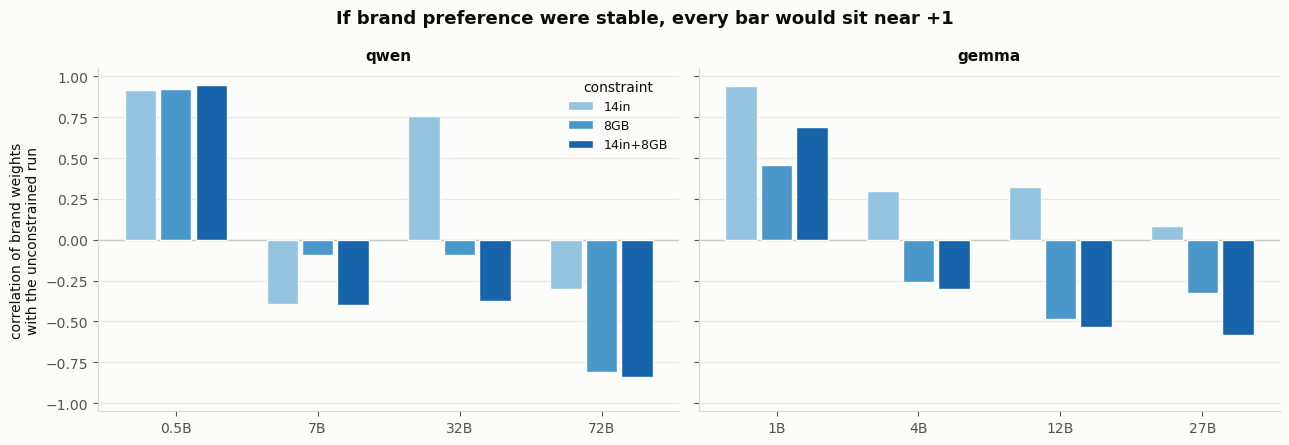

,family,size,constraint,pearson,spearman
0,qwen,0.5,14,0.92,0.9
1,qwen,0.5,8,0.93,0.8
2,qwen,0.5,14_8,0.95,0.8
3,qwen,7,14,-0.39,-0.4
4,qwen,7,8,-0.10,-0.3
5,qwen,7,14_8,-0.40,-0.3
6,qwen,32,14,0.76,0.9
7,qwen,32,8,-0.09,0.0
8,qwen,32,14_8,-0.37,0.0
9,qwen,72,14,-0.30,0.0


In [10]:
# --- Fig 1.5  agreement of each constrained phase with the unconstrained baseline ---
rows = []
for family in ["qwen", "gemma"]:
    for size in SIZE_ORDER[family]:
        base = RUNS.get((family, size, ""))
        if base is None:
            continue
        b0 = [base["feature_centered"][f"brand_{b}"] for b in BRANDS]
        for c in CONSTRAINT_ORDER[1:]:
            r = RUNS.get((family, size, c))
            if r is None:
                continue
            b1 = [r["feature_centered"][f"brand_{b}"] for b in BRANDS]
            rows.append({"family": family, "size": size, "constraint": c,
                         "pearson": np.corrcoef(b0, b1)[0, 1],
                         "spearman": spearmanr(b0, b1)[0]})
agree_brand = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
width = 0.25
for ax, family in zip(axes, ["qwen", "gemma"]):
    sub = agree_brand[agree_brand.family == family]
    sizes = SIZE_ORDER[family]
    x = np.arange(len(sizes))
    for i, c in enumerate(CONSTRAINT_ORDER[1:]):
        vals = [sub[(sub["size"] == s) & (sub.constraint == c)]["pearson"].squeeze() for s in sizes]
        ax.bar(x + (i - 1) * width, vals, width * 0.88,
               color=plt.get_cmap("Blues")(0.4 + 0.2 * i),
               edgecolor=SURFACE, linewidth=1, label=CONSTRAINT_LABEL[c], zorder=3)
    ax.axhline(0, color="#c9c8c4", linewidth=1)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xticks(x, [f"{s}B" for s in sizes])
    ax.set_title(family, fontsize=11, fontweight="bold")
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
axes[0].set_ylabel("correlation of brand weights\nwith the unconstrained run")
axes[0].legend(title="constraint", frameon=False, fontsize=9)
fig.suptitle("If brand preference were stable, every bar would sit near +1",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

agree_brand.round(2)

### What section 1 shows

Read the numbers above before trusting this text — but as it stands:

- **Brand preference is not stable — it often flips.** Adding a constraint that says nothing
  about brand still reorders the brands, and for most models the correlation with the
  unconstrained baseline is **negative**, not just weak.
- **Apple is the clearest case.** It is the top brand in every unconstrained run of both
  families (weights +1.3 to +2.7), and goes negative in almost every constrained run. The
  "favourite brand" does not survive a prompt that mentions screen size or ram.
- **Brand matters less once a constraint exists.** The brand spread shrinks for almost
  every model when a constraint is added — the constrained feature takes over the utility.

**Careful with qwen-0.5B in Fig 1.5.** It is the only model whose bars sit near +1, which
makes it look like the most consistent one. It is not — its brand weights are all within
±0.1 of zero, so that correlation is noise matched against noise. Check Fig 1.4: its spread
is ~0.1 against 2-5 for the larger models. Treat every qwen-0.5B number here as no signal.

# 2. Full parameterization vs feature parameterization

Two ways to fit the same data:

| | parameters | assumes |
|---|---|---|
| **full** | 45 (one per laptop) + 1 bias | nothing — every laptop is free |
| **feature** | 9 (5 brand + 3 screen + 3 ram, minus gauge) + 1 bias | utility is `brand + screen + ram`, no interactions |

The feature model is the full model with interactions forced to zero. The gap between
them is exactly how much the interactions matter.

In [11]:
rows = []
for key, r in RUNS.items():
    items = sorted(r["util_full"])
    a = np.array([r["util_full"][i] for i in items])
    b = np.array([r["util_features"][i] for i in items])
    rows.append({"family": r["family"], "size": r["size"], "constraint": r["constraint"],
                 "pearson": np.corrcoef(a, b)[0, 1], "spearman": spearmanr(a, b)[0],
                 "r2_full": r["r2_full"], "r2_feature": r["r2_feature"],
                 "r2_gap": r["r2_full"] - r["r2_feature"]})
agree_param = pd.DataFrame(rows).sort_values("r2_gap", ascending=False)
agree_param.round(3)

,family,size,constraint,pearson,spearman,r2_full,r2_feature,r2_gap
25,gemma,12,14_8,0.960,0.961,0.833,0.768,0.065
8,qwen,7,14_8,0.962,0.978,0.863,0.799,0.064
22,gemma,4,14_8,0.979,0.980,0.820,0.787,0.033
19,gemma,1,14_8,0.980,0.960,0.710,0.682,0.028
23,gemma,12,14,0.983,0.979,0.827,0.800,0.027
10,qwen,32,14_8,0.985,0.977,0.865,0.840,0.026
28,gemma,27,14_8,0.986,0.996,0.808,0.785,0.023
14,qwen,72,14_8,0.990,0.970,0.898,0.880,0.018
18,gemma,1,8,0.988,0.968,0.722,0.704,0.017
3,qwen,32,14,0.992,0.980,0.818,0.805,0.013


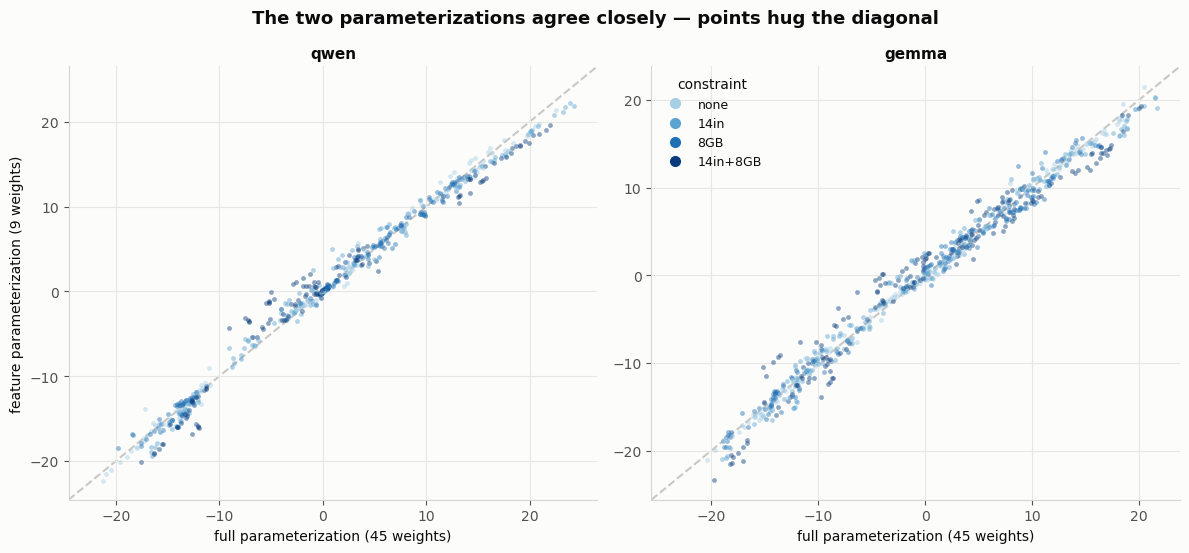

In [12]:
# --- Fig 2.1  full vs feature utility, every laptop of every run ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, family in zip(axes, ["qwen", "gemma"]):
    for key in order_keys(family):
        r = RUNS[key]
        items = sorted(r["util_full"])
        ax.scatter([r["util_full"][i] for i in items],
                   [r["util_features"][i] for i in items],
                   s=12, alpha=0.45, linewidths=0,
                   color=plt.get_cmap("Blues")(0.35 + 0.2 * CONSTRAINT_ORDER.index(r["constraint"])))
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, color="#c9c8c4", linewidth=1.5, linestyle="--", zorder=0)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("full parameterization (45 weights)")
    ax.set_title(family, fontsize=11, fontweight="bold")
    ax.grid(zorder=0); ax.set_axisbelow(True)
axes[0].set_ylabel("feature parameterization (9 weights)")
handles = [Line2D([], [], marker="o", linestyle="", markersize=7,
                  color=plt.get_cmap("Blues")(0.35 + 0.2 * i), label=CONSTRAINT_LABEL[c])
           for i, c in enumerate(CONSTRAINT_ORDER)]
axes[1].legend(handles=handles, title="constraint", frameon=False, fontsize=9)
fig.suptitle("The two parameterizations agree closely — points hug the diagonal",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

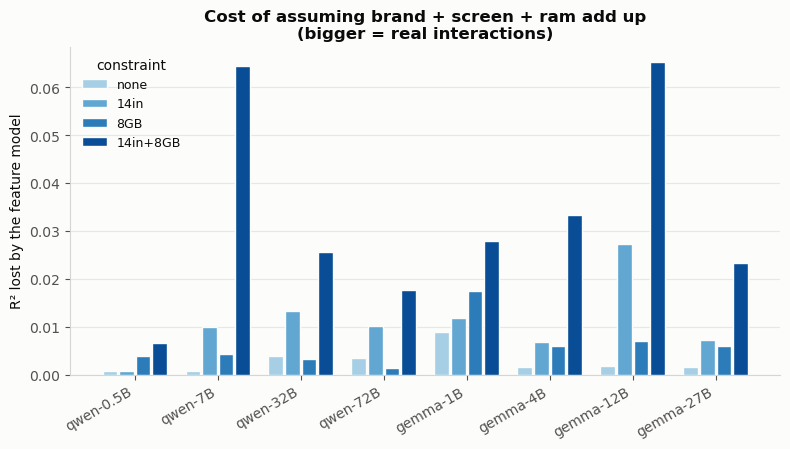

In [13]:
# --- Fig 2.2  where does additivity break down? ---
gap = agree_param.pivot_table(index=["family", "size"], columns="constraint", values="r2_gap")
gap = gap.reindex([(f, s) for f in SIZE_ORDER for s in SIZE_ORDER[f]])[CONSTRAINT_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.6))
x = np.arange(len(gap))
width = 0.2
for i, c in enumerate(CONSTRAINT_ORDER):
    ax.bar(x + (i - 1.5) * width, gap[c].values, width * 0.88,
           color=plt.get_cmap("Blues")(0.35 + 0.18 * i),
           edgecolor=SURFACE, linewidth=1, label=CONSTRAINT_LABEL[c], zorder=3)
ax.set_xticks(x, [f"{f}-{s}B" for f, s in gap.index], rotation=30, ha="right")
ax.set_ylabel("R² lost by the feature model")
ax.legend(title="constraint", frameon=False, fontsize=9)
ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
ax.set_title("Cost of assuming brand + screen + ram add up\n(bigger = real interactions)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.1 How a laptop's weight is built, and how it shifts

Four laptops in a 2x2: a strong brand and a weak brand, each in a version that **satisfies**
both constraints (14-inch + 8GB) and one that **violates** both (16-inch + 16GB).

Stacked bars are the feature model — each bar is `brand + screen + ram`. Negative parts go
below the line, so the **top of the stack is not the total**. Two markers give the totals:

- **white dot** = feature model total (the net of the three blocks)
- **black tick** = full model total (45 free weights, no additivity assumption)

The distance between the two markers is the interaction the feature model cannot see.

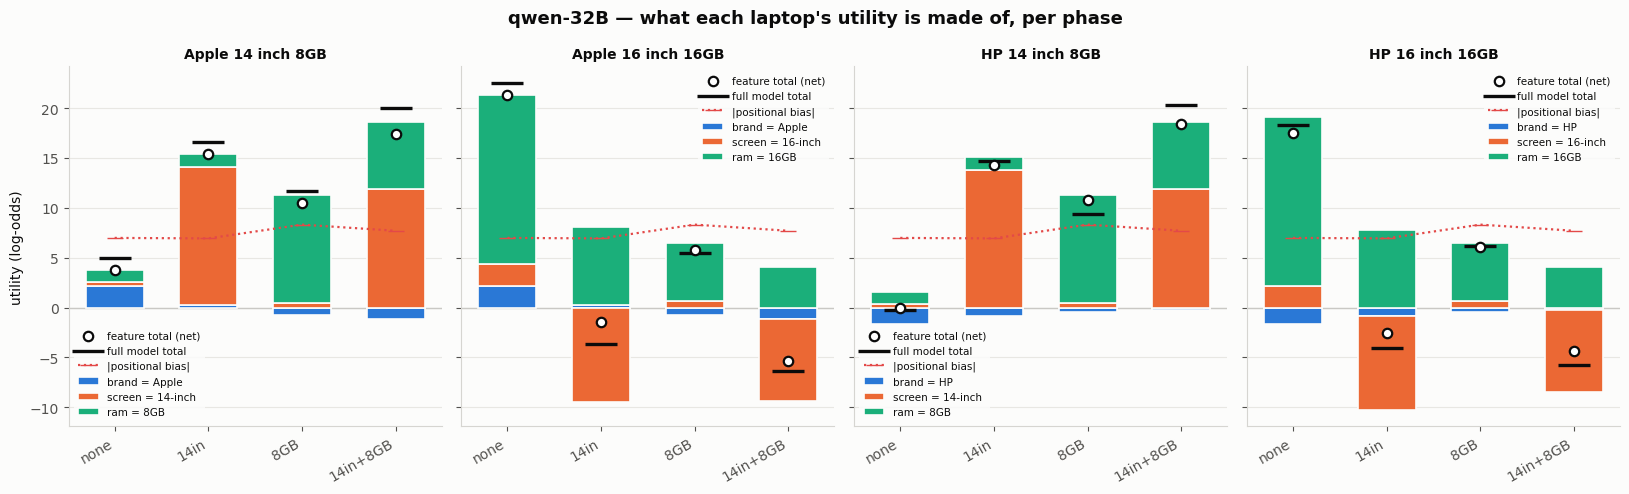

In [14]:
CHOSEN = ["Apple-14-inch-8GB", "Apple-16-inch-16GB", "HP-14-inch-8GB", "HP-16-inch-16GB"]
FAMILY, SIZE = "qwen", "32"          # change these to look at another model


def plot_weight_composition(family, size, items=CHOSEN):
    keys = [(family, size, c) for c in CONSTRAINT_ORDER if (family, size, c) in RUNS]
    fig, axes = plt.subplots(1, len(items), figsize=(4.1 * len(items), 5), sharey=True)
    x = np.arange(len(keys))

    for ax, item in zip(np.atleast_1d(axes), items):
        feats = RUNS[keys[0]]["item_feature_map"][item]
        pos = np.zeros(len(keys))
        neg = np.zeros(len(keys))
        for f in FEATURES:
            vals = np.array([RUNS[k]["feature_centered"][f"{f}_{feats[f]}"] for k in keys])
            bottom = np.where(vals >= 0, pos, neg)
            ax.bar(x, vals, 0.62, bottom=bottom, color=FEATURE_COLOR[f],
                   edgecolor=SURFACE, linewidth=1.2, label=f"{f} = {feats[f]}", zorder=3)
            pos += np.where(vals >= 0, vals, 0)
            neg += np.where(vals < 0, vals, 0)

        # the stack's visual top is NOT the total once anything is negative,
        # so mark both totals explicitly
        net = [RUNS[k]["util_features"][item] for k in keys]
        full = [RUNS[k]["util_full"][item] for k in keys]
        ax.scatter(x, net, marker="o", s=46, color="#ffffff", edgecolor=INK,
                   linewidths=1.6, zorder=6, label="feature total (net)")
        ax.scatter(x, full, marker="_", s=520, color=INK, linewidths=2.4, zorder=5,
                   label="full model total")
        # positional bias on the same axis - how big the whole utility is next to it
        gam = [abs(RUNS[k]["gamma"]) for k in keys]
        ax.plot(x, gam, color="#e34948", linewidth=1.6, linestyle=":", marker="_",
                markersize=12, zorder=4, label="|positional bias|")
        ax.axhline(0, color="#c9c8c4", linewidth=1, zorder=1)
        ax.set_xticks(x, [CONSTRAINT_LABEL[k[2]] for k in keys], rotation=30, ha="right")
        ax.set_title(item.replace("-", " "), fontsize=10, fontweight="bold")
        ax.legend(fontsize=7.5, loc="best", framealpha=0.85, edgecolor="none")
        ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)

    np.atleast_1d(axes)[0].set_ylabel("utility (log-odds)")
    fig.suptitle(f"{family}-{size}B — what each laptop's utility is made of, per phase",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_weight_composition(FAMILY, SIZE)

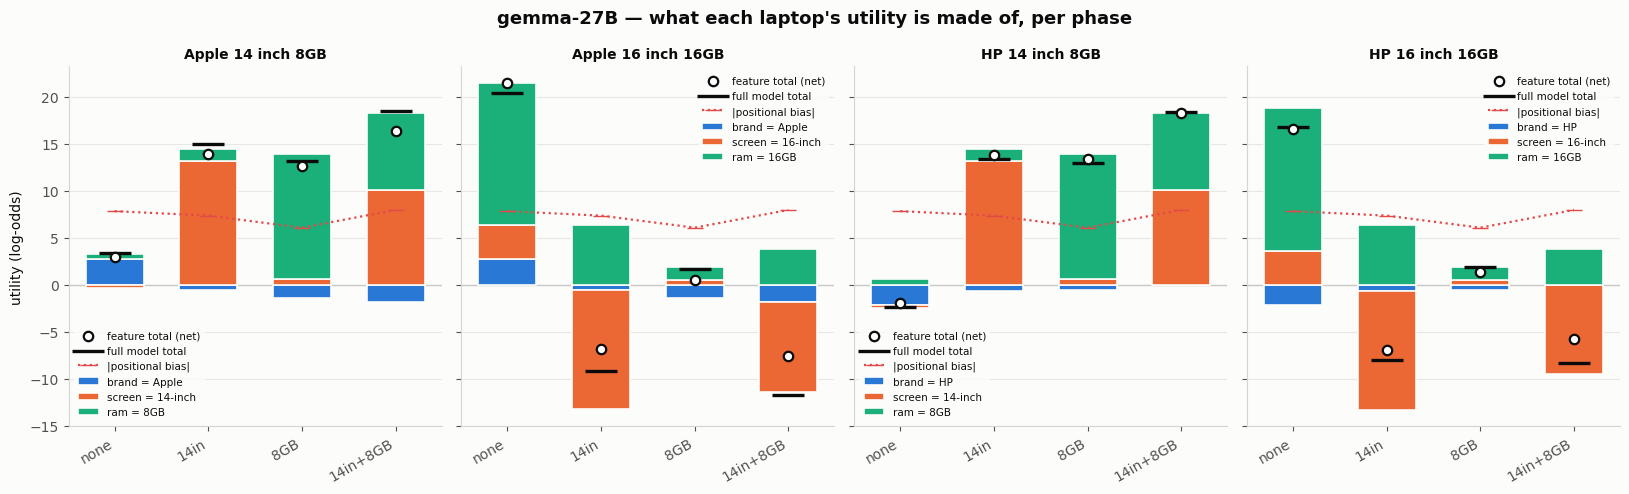

In [15]:
plot_weight_composition("gemma", "27")

### What section 2 shows

- The two parameterizations agree very closely (Pearson ~0.96-1.00). The additive
  `brand + screen + ram` model is a good description of what the model is doing.
- The R² the feature model gives up is tiny (~0.001-0.01) **except under the double
  constraint `14_8`**, where it jumps to ~0.03-0.07. Two constraints at once create a real
  interaction: "satisfies both" is worth more than "satisfies screen" plus "satisfies ram".
- In the stacked bars, the ram and screen blocks explode once their constraint is named,
  while the brand block stays small. The contract dominates the model's own preference.

# 3. Other views

Three things the sections above kept bumping into.

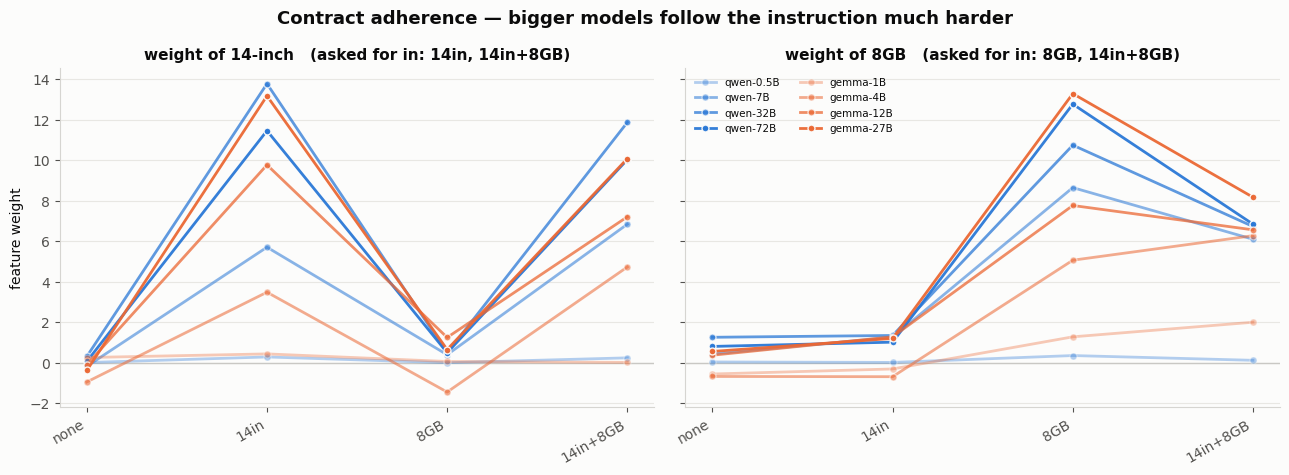

In [16]:
# --- Fig 3.1  does the model actually obey the contract? ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (feat, level, on) in zip(axes, [("screen", "14-inch", ["14", "14_8"]),
                                        ("ram", "8GB", ["8", "14_8"])]):
    for family in ["qwen", "gemma"]:
        for size in SIZE_ORDER[family]:
            keys = [(family, size, c) for c in CONSTRAINT_ORDER if (family, size, c) in RUNS]
            y = [RUNS[k]["feature_centered"][f"{feat}_{level}"] for k in keys]
            ax.plot(np.arange(len(keys)), y, marker="o", markersize=5,
                    color="#2a78d6" if family == "qwen" else "#eb6834",
                    alpha=0.35 + 0.2 * SIZE_ORDER[family].index(size),
                    markeredgecolor=SURFACE, label=f"{family}-{size}B", zorder=3)
    ax.axhline(0, color="#c9c8c4", linewidth=1)
    ax.set_xticks(range(4), [CONSTRAINT_LABEL[c] for c in CONSTRAINT_ORDER], rotation=30, ha="right")
    ax.set_title(f"weight of {level}   (asked for in: {', '.join(CONSTRAINT_LABEL[c] for c in on)})",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
axes[0].set_ylabel("feature weight")
axes[1].legend(fontsize=7.5, frameon=False, ncol=2)
fig.suptitle("Contract adherence — bigger models follow the instruction much harder",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

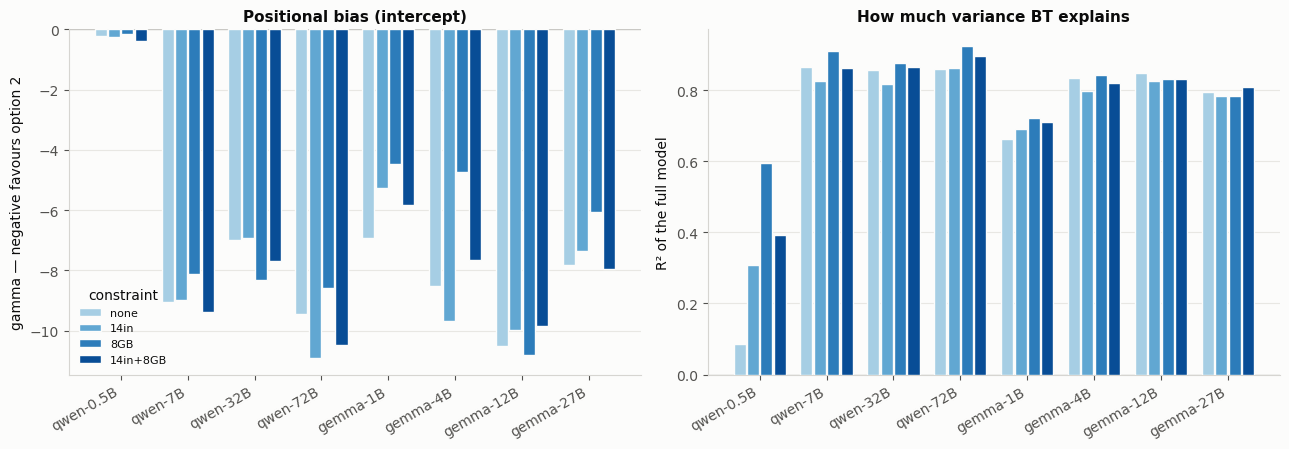

In [17]:
# --- Fig 3.2  positional bias, and how well BT fits at all ---
diag = pd.DataFrame([{"family": r["family"], "size": r["size"], "constraint": r["constraint"],
                      "gamma": r["gamma"], "r2_full": r["r2_full"]} for r in RUNS.values()])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for i, (col, title, ylab) in enumerate([
        ("gamma", "Positional bias (intercept)", "gamma — negative favours option 2"),
        ("r2_full", "How much variance BT explains", "R² of the full model")]):
    ax = axes[i]
    piv = (diag.pivot_table(index=["family", "size"], columns="constraint", values=col)
           .reindex([(f, s) for f in SIZE_ORDER for s in SIZE_ORDER[f]])[CONSTRAINT_ORDER])
    x = np.arange(len(piv))
    for j, c in enumerate(CONSTRAINT_ORDER):
        ax.bar(x + (j - 1.5) * 0.2, piv[c].values, 0.18,
               color=plt.get_cmap("Blues")(0.35 + 0.18 * j),
               edgecolor=SURFACE, linewidth=1, label=CONSTRAINT_LABEL[c], zorder=3)
    ax.axhline(0, color="#c9c8c4", linewidth=1)
    ax.set_xticks(x, [f"{f}-{s}B" for f, s in piv.index], rotation=30, ha="right")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylab)
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
axes[0].legend(title="constraint", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

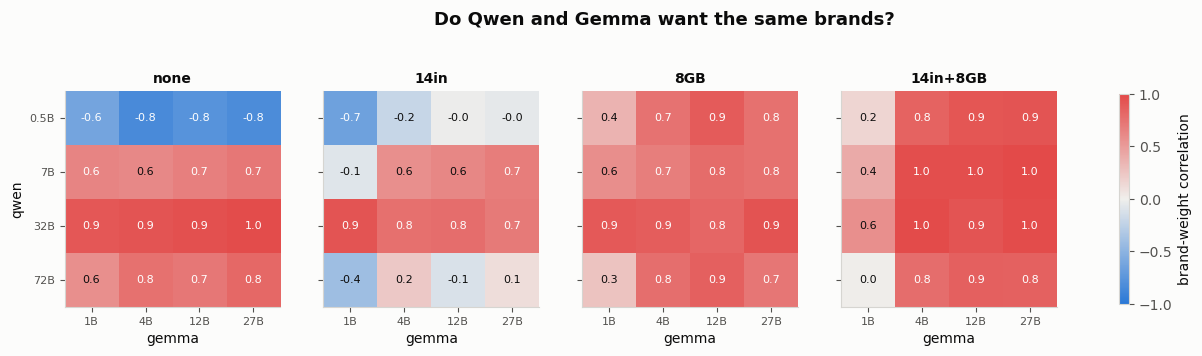

In [18]:
# --- Fig 3.3  do the two model families want the same brands? ---
pairs = []
for size_q in SIZE_ORDER["qwen"]:
    for size_g in SIZE_ORDER["gemma"]:
        for c in CONSTRAINT_ORDER:
            a, b = RUNS.get(("qwen", size_q, c)), RUNS.get(("gemma", size_g, c))
            if a is None or b is None:
                continue
            wa = [a["feature_centered"][f"brand_{x}"] for x in BRANDS]
            wb = [b["feature_centered"][f"brand_{x}"] for x in BRANDS]
            pairs.append({"qwen": f"{size_q}B", "gemma": f"{size_g}B",
                          "constraint": c, "pearson": np.corrcoef(wa, wb)[0, 1]})
cross = pd.DataFrame(pairs)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9), sharey=True)
for ax, c in zip(axes, CONSTRAINT_ORDER):
    m = (cross[cross.constraint == c]
         .pivot_table(index="qwen", columns="gemma", values="pearson")
         .reindex([f"{s}B" for s in SIZE_ORDER["qwen"]])[[f"{s}B" for s in SIZE_ORDER["gemma"]]])
    im = ax.imshow(m.values, cmap=DIVERGING, norm=TwoSlopeNorm(0, -1, 1))
    ax.set_xticks(range(m.shape[1]), m.columns, fontsize=8)
    ax.set_yticks(range(m.shape[0]), m.index, fontsize=8)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            ax.text(j, i, f"{m.values[i, j]:.1f}", ha="center", va="center", fontsize=8,
                    color="#ffffff" if abs(m.values[i, j]) > 0.62 else INK)
    ax.set_title(CONSTRAINT_LABEL[c], fontsize=10, fontweight="bold")
    ax.set_xlabel("gemma")
    ax.grid(False)
axes[0].set_ylabel("qwen")
fig.colorbar(im, ax=axes, shrink=0.7, label="brand-weight correlation")
fig.suptitle("Do Qwen and Gemma want the same brands?", fontsize=13, fontweight="bold")
plt.show()

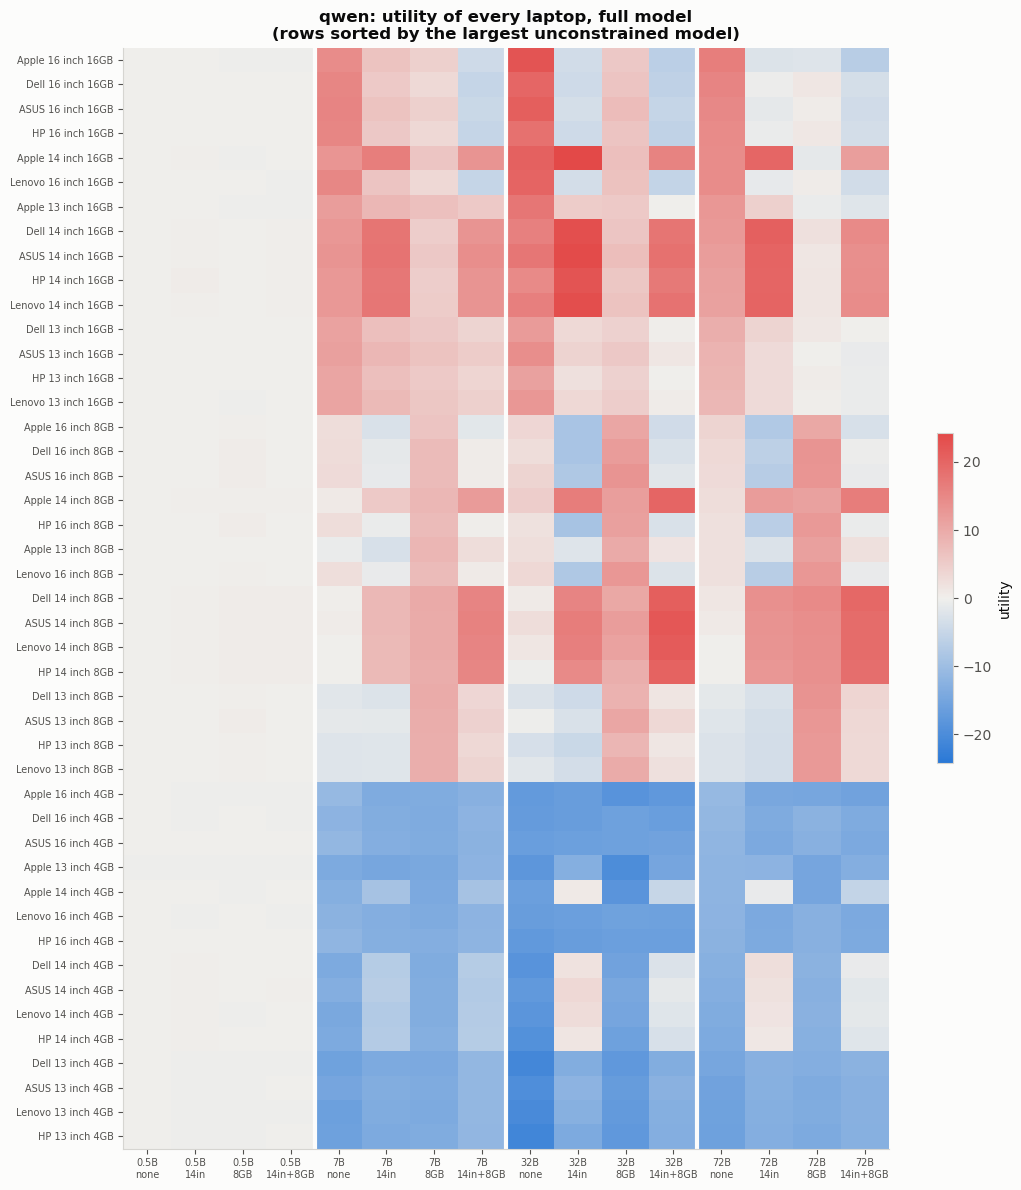

In [19]:
# --- Fig 3.4  the whole 45-laptop ranking, full model, as a heatmap ---
FAM = "qwen"
keys = order_keys(FAM)
items = sorted(RUNS[keys[0]]["util_full"], key=lambda it: -RUNS[(FAM, SIZE_ORDER[FAM][-1], "")]["util_full"][it])
mat = np.array([[RUNS[k]["util_full"][it] for k in keys] for it in items])

fig, ax = plt.subplots(figsize=(11, 12))
v = float(np.abs(mat).max())
im = ax.imshow(mat, cmap=DIVERGING, norm=TwoSlopeNorm(0, -v, v), aspect="auto")
ax.set_yticks(range(len(items)), [i.replace("-", " ") for i in items], fontsize=7)
ax.set_xticks(range(len(keys)), [f"{k[1]}B\n{CONSTRAINT_LABEL[k[2]]}" for k in keys], fontsize=7)
for i in range(4, len(keys), 4):
    ax.axvline(i - 0.5, color=SURFACE, linewidth=3)
ax.set_title(f"{FAM}: utility of every laptop, full model\n(rows sorted by the largest "
             f"unconstrained model)", fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.3, label="utility")
ax.grid(False)
plt.tight_layout()
plt.show()

# 4. Do the p-values make sense?

The fit reports p-values around `1e-30` and prints "significant" for nearly everything.
That should make us suspicious. Two separate problems:

**Problem 1 — the rows are not independent.** OLS assumes 9900 independent observations.
But each unordered pair `{A,B}` appears as `(A,B)` and `(B,A)`, and each of those is
repeated over 5 prompt templates. So **10 rows share the same item pair** — there are only
990 genuinely independent pairs, not 9900 rows. Standard errors computed as if there were
9900 will be too small, and the p-values too optimistic.

**Problem 2 — n is huge.** With ~10k rows, even a meaningless effect clears p < 0.05.
Significance stops being informative; effect size is what matters.

The check below refits with **cluster-robust standard errors, clustered by unordered pair**,
and compares.

In [20]:
KEY = ("qwen", "32", "")          # change to inspect another run
r = RUNS[KEY]
tbl = r["coef_table"]

print(f"run: {KEY}   rows=9900   independent pairs={r['n_clusters']}   R2={r['r2_feature']:.3f}")

# how much of the residual variance sits BETWEEN pairs rather than within?
rdf = pd.DataFrame({"pair": r["pair_id"], "resid": r["resid"]})
icc = rdf.groupby("pair")["resid"].mean().var() / rdf["resid"].var()
print(f"share of residual variance that is between-pair: {icc:.3f}  "
      f"(0 would mean rows inside a pair really are unrelated)")

tbl.round(4)

run: ('qwen', '32', '')   rows=9900   independent pairs=990   R2=0.853
share of residual variance that is between-pair: 0.176  (0 would mean rows inside a pair really are unrelated)


,term,coef,se_ols,se_cluster,se_inflation,p_ols,p_cluster
0,gamma (positional bias),-6.9840,0.0870,0.1155,1.3282,0.0,0.0000
1,brand_Apple,1.6037,0.1923,0.5118,2.6621,0.0,0.0017
2,brand_Dell,-1.4503,0.1923,0.5159,2.6832,0.0,0.0049
3,brand_HP,-2.2115,0.1923,0.5332,2.7736,0.0,0.0000
4,brand_Lenovo,-0.9756,0.1923,0.5200,2.7047,0.0,0.0606
5,screen_14-inch,2.8056,0.1489,0.3975,2.6693,0.0,0.0000
6,screen_16-inch,4.6533,0.1489,0.3923,2.6340,0.0,0.0000
7,ram_4GB,-35.1943,0.1489,0.4256,2.8581,0.0,0.0000
8,ram_8GB,-15.6954,0.1489,0.4301,2.8883,0.0,0.0000


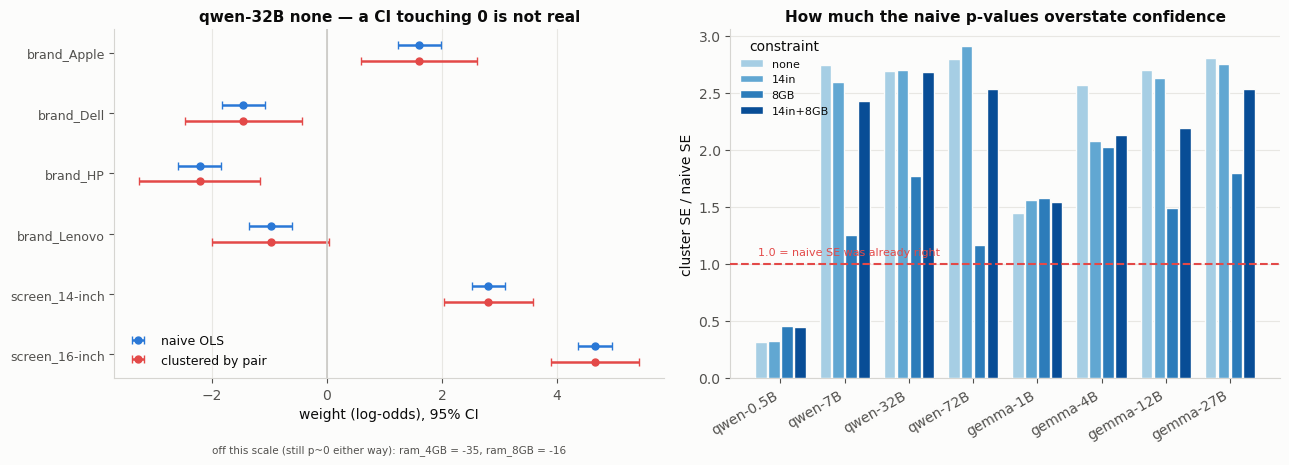

In [21]:
# --- Fig 4.1  the same coefficients with honest error bars ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# left: 95% CI, naive vs clustered.
# gamma and the ram terms are 10-35 log-odds and would squash everything else flat,
# so this panel shows the terms where the correction actually changes the verdict.
big = tbl[tbl.coef.abs() >= 10]
t = tbl[(tbl.coef.abs() < 10) & (tbl.term != "gamma (positional bias)")].reset_index(drop=True)
y = np.arange(len(t))
axes[0].errorbar(t.coef, y - 0.13, xerr=1.96 * t.se_ols, fmt="o", markersize=5,
                 color="#2a78d6", capsize=3, linewidth=1.8, label="naive OLS")
axes[0].errorbar(t.coef, y + 0.13, xerr=1.96 * t.se_cluster, fmt="o", markersize=5,
                 color="#e34948", capsize=3, linewidth=1.8, label="clustered by pair")
axes[0].axvline(0, color="#c9c8c4", linewidth=1.2)
axes[0].set_yticks(y, t.term, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("weight (log-odds), 95% CI")
axes[0].set_title(f"{KEY[0]}-{KEY[1]}B {CONSTRAINT_LABEL[KEY[2]]} — a CI touching 0 is not real",
                  fontsize=11, fontweight="bold")
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
axes[0].grid(axis="x", zorder=0); axes[0].set_axisbelow(True)
off = ", ".join(f"{r.term} = {r.coef:.0f}" for r in big.itertuples())
axes[0].text(0.5, -0.19, f"off this scale (still p~0 either way): {off}",
             transform=axes[0].transAxes, ha="center", va="top",
             fontsize=7.5, color=INK_MUTED)

# right: how much SEs are understated, across every run
infl = pd.DataFrame([
    {"family": rr["family"], "size": rr["size"], "constraint": rr["constraint"],
     "median_inflation": rr["coef_table"].iloc[1:]["se_inflation"].median()}
    for rr in RUNS.values()])
piv = (infl.pivot_table(index=["family", "size"], columns="constraint",
                        values="median_inflation")
       .reindex([(f, s) for f in SIZE_ORDER for s in SIZE_ORDER[f]])[CONSTRAINT_ORDER])
x = np.arange(len(piv))
for j, c in enumerate(CONSTRAINT_ORDER):
    axes[1].bar(x + (j - 1.5) * 0.2, piv[c].values, 0.18,
                color=plt.get_cmap("Blues")(0.35 + 0.18 * j),
                edgecolor=SURFACE, linewidth=1, label=CONSTRAINT_LABEL[c], zorder=3)
axes[1].axhline(1, color="#e34948", linewidth=1.5, linestyle="--", zorder=4)
axes[1].text(-0.35, 1.06, "1.0 = naive SE was already right", fontsize=8,
             color="#e34948", ha="left", va="bottom")
axes[1].set_xticks(x, [f"{f}-{s}B" for f, s in piv.index], rotation=30, ha="right")
axes[1].set_ylabel("cluster SE / naive SE")
axes[1].set_title("How much the naive p-values overstate confidence",
                  fontsize=11, fontweight="bold")
axes[1].legend(title="constraint", frameon=False, fontsize=8)
axes[1].grid(axis="y", zorder=0); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.show()

In [22]:
# --- which conclusions actually change once the SEs are honest? ---
rows = []
for key, rr in RUNS.items():
    t = rr["coef_table"].iloc[1:]
    flipped = t[(t.p_ols < 0.05) & (t.p_cluster >= 0.05)]["term"].tolist()
    rows.append({"family": rr["family"], "size": rr["size"],
                 "constraint": rr["constraint"] or "none",
                 "sig_ols": int((t.p_ols < 0.05).sum()),
                 "sig_cluster": int((t.p_cluster < 0.05).sum()),
                 "n_terms": len(t),
                 "lost": ", ".join(flipped) if flipped else "-"})
flips = pd.DataFrame(rows).sort_values(["family", "size", "constraint"])
flips

,family,size,constraint,sig_ols,sig_cluster,n_terms,lost
17,gemma,1,14,6,6,8,-
19,gemma,1,14_8,8,7,8,brand_Lenovo
18,gemma,1,8,7,7,8,-
16,gemma,1,none,7,7,8,-
23,gemma,12,14,7,7,8,-
25,gemma,12,14_8,7,6,8,brand_HP
24,gemma,12,8,7,7,8,-
30,gemma,12,none,7,7,8,-
26,gemma,27,14,7,6,8,brand_Dell
28,gemma,27,14_8,7,7,8,-


### Verdict on the p-values

**They are too optimistic, but the main conclusions hold.**

- Clustering by unordered pair inflates the standard errors by roughly **2.6x to 3.1x**
  for every real model. So a naive p-value of `1e-7` is really more like `0.06`.
- About **18% of the residual variance is between-pair**, which confirms the rows inside a
  pair are not independent — exactly what OLS assumes away.
- The **big effects survive easily**: ram, screen, and the positional bias stay at
  p ≈ 0 even with clustered errors. Those are not artifacts.
- What flips is the **borderline brand terms** — e.g. in qwen-32B unconstrained,
  `brand_Lenovo` goes from p = 4e-7 to p = 0.061. So some individual brand weights we might
  have called "real" are not.
- **qwen-0.5B is the odd one out**: its inflation factor is *below* 1. That is not good
  news — its R² is 0.085 and its effects are ~0.1 log-odds. It is fitting noise, and with
  n = 9900 even noise comes out "significant". Judge it by effect size, not by p.

**Practical rule for this project:** stop reading the printed p-values as-is. Either use
clustered SEs, or judge an effect by whether it is large compared to the positional bias
(which is 5-11 log-odds — bigger than every brand effect we have measured).

# Summary

1. **Brand preference is not robust.** Constraints that say nothing about brand still
   reorder the brands, and correlation with the unconstrained run is frequently near zero
   or negative. Whatever "the model's brand preference" is, it is not a stable object that
   survives a change in the prompt.
2. **Adding a constraint flattens brand.** The brand spread shrinks in almost every model
   once any constraint is present — the named feature soaks up the utility.
3. **The additive feature model is a good fit** (Pearson ~0.96-1.00 against the full
   45-parameter model), so the 9-weight description is not losing much — *except* under two
   simultaneous constraints, where a real interaction appears.
4. **Contract adherence scales with model size.** qwen-0.5B barely responds to the
   instruction; qwen-32/72B and gemma-12/27B move the constrained feature by 10+ log-odds.
5. **qwen-0.5B is noise** on every measure (R² 0.085 unconstrained, brand spread ~0.1,
   positional bias ~0.2). Do not read anything into its preferences.
6. **Positional bias is large** (gamma around -5 to -11 for every model except 0.5B) and
   does not go away with size. In Fig 1.4 the red ticks sit far above every brand bar —
   the nuisance is 2-5x the preference we are trying to measure. Strong reason to keep
   working on the PMI / label-bias correction.
7. **The printed p-values overstate confidence by ~2.6-3x** (Section 4). The rows are not
   independent — 10 of them share each item pair. Big effects survive clustered standard
   errors; borderline brand terms do not.